# Climate indices — quickstart (live)

The `climate-indices` backend fetches monthly **teleconnection index**
series (ENSO/ONI, NAO, AO, PDO, AMO, SOI, PNA, …) from two open ASCII
sources — **NOAA PSL** and the **KNMI Climate Explorer** — and returns
them as a tidy long-format `pandas.DataFrame` with columns `date`,
`index`, `value`, `source`.

These indices are **global scalar monthly series**: one number per
month, no geometry. So unlike the raster backends there is no bounding
box and no grid — you ask for index ids and a date window, and you get
back a time series.

This notebook fetches data **live** from both sources.

In [1]:
import matplotlib.pyplot as plt
from earthlens.earthlens import EarthLens

## A single index (NOAA PSL)

Pass the index id(s) in `variables=` and a `[start, end]` window. The
Oceanic Niño Index (`oni`) is the canonical ENSO indicator — a 3-month
running mean of the Niño 3.4 sea-surface-temperature anomaly.

In [2]:
oni = EarthLens(
    data_source='climate-indices',
    variables=['oni'],
    start='1990-01-01',
    end='2020-12-31',
    path='ci_out',
).download()

oni.head()

2026-06-26 17:01:55.848 | INFO     | earthlens.climate_indices.backend:_log_citations:403 - ClimateIndices source citation: NOAA Physical Sciences Laboratory (PSL), Boulder, Colorado, USA, from their website at https://psl.noaa.gov/data/climateindices/


2026-06-26 17:01:55.849 | INFO     | earthlens.climate_indices.backend:download:357 - ClimateIndices: 372 row(s) across 1 index/indices written to C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\climate-indices\docs\examples\climate_indices\ci_out\climate_indices_oni.csv


,date,index,value,source
0,1990-01-01,oni,0.14,noaa-psl
1,1990-02-01,oni,0.21,noaa-psl
2,1990-03-01,oni,0.28,noaa-psl
3,1990-04-01,oni,0.29,noaa-psl
4,1990-05-01,oni,0.29,noaa-psl


Every row is one month (`date` is the first of the month). The
missing-value sentinel from the source file is mapped to `NaN` (kept,
not dropped, so gaps stay visible). `download()` also wrote the table to
a CSV under `path`.

In [3]:
print('rows:', len(oni))
print('span:', oni['date'].min().date(), '->', oni['date'].max().date())
print('source:', oni['source'].unique().tolist())
oni['value'].describe()[['min', 'mean', 'max']]

rows: 372
span: 1990-01-01 -> 2020-12-01
source: ['noaa-psl']


min    -1.660000
mean    0.056425
max     2.750000
Name: value, dtype: float64

## Several indices, two sources at once

Ask for more than one id and the result concatenates them, told apart by
the `index` (and `source`) column. Here `oni` and `nao` come from NOAA
PSL while `amo` (the detrended Atlantic Multidecadal Oscillation) comes
from the KNMI Climate Explorer — two different ASCII dialects, one tidy
frame.

In [4]:
df = EarthLens(
    data_source='climate-indices',
    variables=['oni', 'nao', 'amo'],
    start='1980-01-01',
    end='2020-12-31',
    path='ci_out',
).download()

df.groupby('index').agg(
    rows=('value', 'size'),
    source=('source', 'first'),
    first=('date', 'min'),
    last=('date', 'max'),
)

2026-06-26 17:01:57.080 | INFO     | earthlens.climate_indices.backend:_log_citations:403 - ClimateIndices source citation: NOAA Physical Sciences Laboratory (PSL), Boulder, Colorado, USA, from their website at https://psl.noaa.gov/data/climateindices/


2026-06-26 17:01:57.081 | INFO     | earthlens.climate_indices.backend:_log_citations:403 - ClimateIndices source citation: KNMI Climate Explorer (https://climexp.knmi.nl), Royal Netherlands Meteorological Institute.


2026-06-26 17:01:57.083 | INFO     | earthlens.climate_indices.backend:download:357 - ClimateIndices: 1476 row(s) across 3 index/indices written to C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\climate-indices\docs\examples\climate_indices\ci_out\climate_indices_oni_nao_amo.csv


,rows,source,first,last
index,,,,
amo,492,knmi-climexp,1980-01-01,2020-12-01
nao,492,noaa-psl,1980-01-01,2020-12-01
oni,492,noaa-psl,1980-01-01,2020-12-01


## Pivot to wide form and plot

The long frame pivots to a month × index table in one call — handy for
plotting or correlating indices against each other.

In [5]:
wide = df.pivot(index='date', columns='index', values='value')
wide.tail()

index,amo,nao,oni
date,,,
2020-08-01,0.182089,0.03,-0.53
2020-09-01,-0.120102,1.11,-0.85
2020-10-01,0.065796,-0.20,-1.12
2020-11-01,-0.093541,2.54,-1.20
2020-12-01,0.184788,-0.37,-1.08


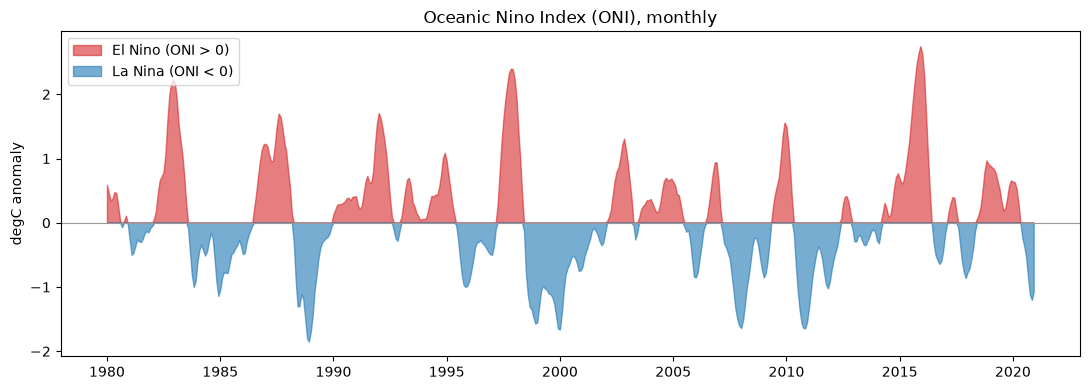

In [6]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.axhline(0.0, color='0.6', lw=0.8)
ax.fill_between(
    wide.index,
    0,
    wide['oni'].clip(lower=0),
    color='tab:red',
    alpha=0.6,
    label='El Nino (ONI > 0)',
)
ax.fill_between(
    wide.index,
    0,
    wide['oni'].clip(upper=0),
    color='tab:blue',
    alpha=0.6,
    label='La Nina (ONI < 0)',
)
ax.set_title('Oceanic Nino Index (ONI), monthly')
ax.set_ylabel('degC anomaly')
ax.legend(loc='upper left')
fig.tight_layout()

## Roll up to annual means

There is no server-side aggregation for these scalar series (and
`download(aggregate=...)` is rejected — see the catalog/behaviour
notebook). Any rollup is a one-liner on the returned frame:

In [7]:
annual = (
    df.assign(year=df['date'].dt.year)
    .groupby(['index', 'year'])['value']
    .mean()
    .unstack('index')
)
annual.tail()

index,amo,nao,oni
year,,,
2016,-0.055270,-0.117500,0.423333
2017,0.126070,0.173333,-0.115000
2018,0.018962,1.093333,0.094167
2019,-0.017355,-0.393333,0.575000
2020,0.039339,0.265000,-0.271667


## Takeaway

- `EarthLens(data_source='climate-indices', variables=[...], start=...,
  end=...)` returns a long `date / index / value / source` frame.
- Multiple indices — even across the two sources — come back in one
  frame, distinguished by `index` / `source`.
- The result is plain pandas: pivot, plot, resample, correlate as you
  like. See the [catalog & behaviour](02_catalog_and_behavior.ipynb)
  notebook for the shipped index list and the no-bbox / no-aggregate
  design.